In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# ============================================================
# Generate Dataset
# ============================================================
np.random.seed(42)
n = 1000

x = np.random.uniform(0, 10, n)
x = np.sort(x)
y = 3 * np.sin(x) + 0.5 * x + np.random.normal(0, 1.2, n)

df = pd.DataFrame({'x': x, 'y': y})

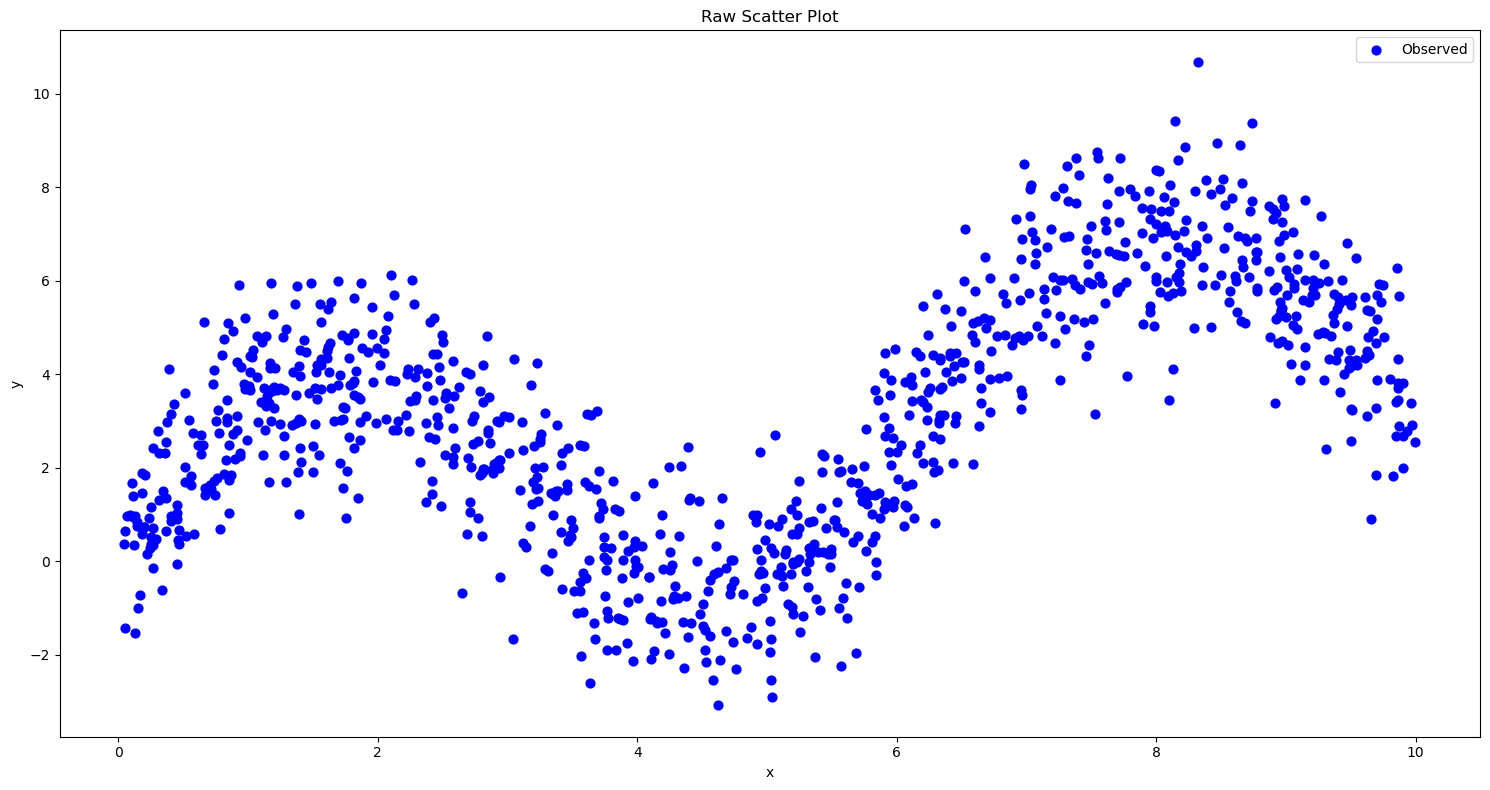

In [35]:
# ============================================================
# Graph 1 - Raw Scatter Plot
# ============================================================
plt.figure(figsize=(15, 8))
plt.scatter(df['x'], df['y'], color='blue', s=40, label='Observed')
plt.title('Raw Scatter Plot')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# Local Linear Regression (Non-Parametric)
# ============================================================
xy = df[['x', 'y']].values
x1 = xy[:, 0]
y1 = xy[:, 1]
n  = len(xy)
m  = 30

yh = np.zeros(n)

for i in range(n):
    # select focal point
    f_point = x1[i]

    # compute distances from focal point
    x0 = x1 - f_point

    # build array: abs distance | signed distance | x | y
    axy = np.column_stack([np.abs(x0), x0, xy])

    # sort by absolute distance ascending
    axy = axy[axy[:, 0].argsort()]

    # select m nearest neighbours
    x_nn = axy[:m, 1]
    y_nn = axy[:m, 3]

    # design matrix with intercept
    X = np.column_stack([np.ones(m), x_nn])

    # OLS: bh = (X'X)^-1 X'y
    bh = np.linalg.inv(X.T @ X) @ X.T @ y_nn

    # fitted value at focal point (intercept = value at x0=0)
    yh[i] = bh[0]

df['yh'] = yh

print(df.head(10))

          x         y        yh
0  0.046320  0.375312  0.341932
1  0.050616 -1.425323  0.351570
2  0.055221  0.649427  0.361904
3  0.069521  0.975859  0.393991
4  0.091971  0.993257  0.444364
5  0.108377  1.675619  0.481177
6  0.109958  1.384896  0.484726
7  0.113536  0.947662  0.492755
8  0.121545  0.340311  0.510724
9  0.130019 -1.539184  0.529740


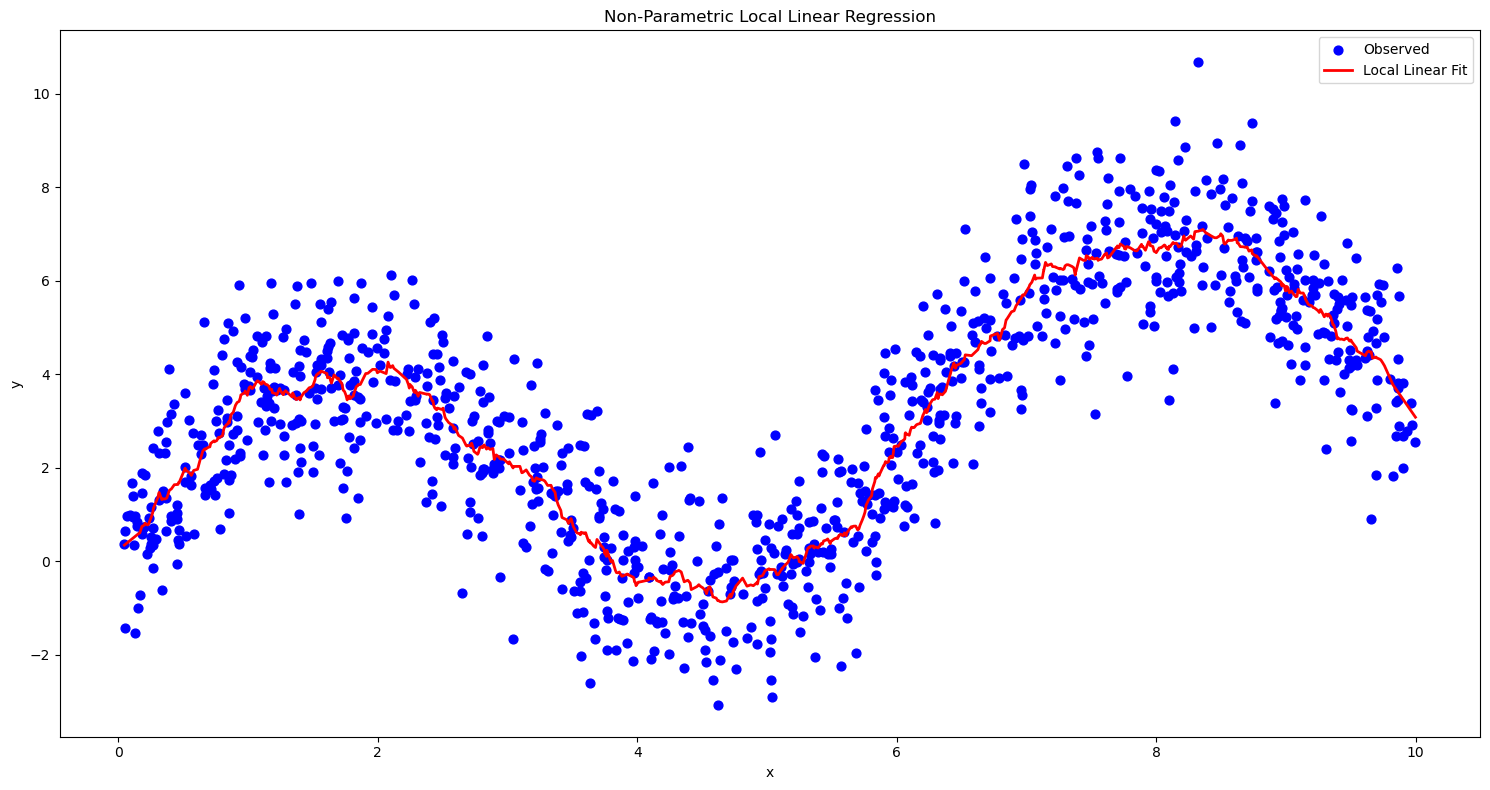

In [33]:
# ============================================================
# Graph 2 - Observed vs Fitted Overlay
# ============================================================
plt.figure(figsize=(15, 8))
plt.scatter(df['x'], df['y'], 
            color='blue', s=40, label='Observed', zorder=2)
plt.plot(df['x'], df['yh'], 
         color='red', linewidth=2, label='Local Linear Fit')
plt.title('Non-Parametric Local Linear Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# Optimal Bandwidth Selection via LOOCV
# ============================================================

def local_linear_fit(x1, y1, m):
    n = len(x1)
    yh = np.zeros(n)
    for i in range(n):
        f_point = x1[i]
        x0      = x1 - f_point
        axy     = np.column_stack([np.abs(x0), x0, x1, y1])
        axy     = axy[axy[:, 0].argsort()]
        x_nn    = axy[:m, 1]
        y_nn    = axy[:m, 3]
        X       = np.column_stack([np.ones(m), x_nn])
        bh      = np.linalg.inv(X.T @ X) @ X.T @ y_nn
        yh[i]   = bh[0]
    return yh


def loocv(x1, y1, m):
    n      = len(x1)
    errors = np.zeros(n)
    for i in range(n):
        # remove observation i
        x_train = np.delete(x1, i)
        y_train = np.delete(y1, i)
        x_test  = x1[i]
        y_test  = y1[i]

        # compute distances from test point to training points
        x0  = x_train - x_test
        axy = np.column_stack([np.abs(x0), x0, x_train, y_train])
        axy = axy[axy[:, 0].argsort()]

        # use m neighbours but cap at available training points
        m_use = min(m, len(x_train))
        x_nn  = axy[:m_use, 1]
        y_nn  = axy[:m_use, 3]

        X    = np.column_stack([np.ones(m_use), x_nn])
        bh   = np.linalg.inv(X.T @ X) @ X.T @ y_nn
        yh_i = bh[0]

        errors[i] = (y_test - yh_i) ** 2

    return np.mean(errors)

In [39]:
# candidate bandwidth values
m_candidates = range(5, 60, 5)
cv_errors    = []

for m in m_candidates:
    err = loocv(x, y, m)
    cv_errors.append(err)
    print(f"m = {m:3d}  |  LOOCV MSE = {err:.4f}")

# optimal m
optimal_m  = list(m_candidates)[np.argmin(cv_errors)]
print(f"\nOptimal m: {optimal_m}")

m =   5  |  LOOCV MSE = 1.8331
m =  10  |  LOOCV MSE = 1.5364
m =  15  |  LOOCV MSE = 1.5122
m =  20  |  LOOCV MSE = 1.4842
m =  25  |  LOOCV MSE = 1.4653
m =  30  |  LOOCV MSE = 1.4548
m =  35  |  LOOCV MSE = 1.4555
m =  40  |  LOOCV MSE = 1.4481
m =  45  |  LOOCV MSE = 1.4419
m =  50  |  LOOCV MSE = 1.4357
m =  55  |  LOOCV MSE = 1.4344

Optimal m: 55


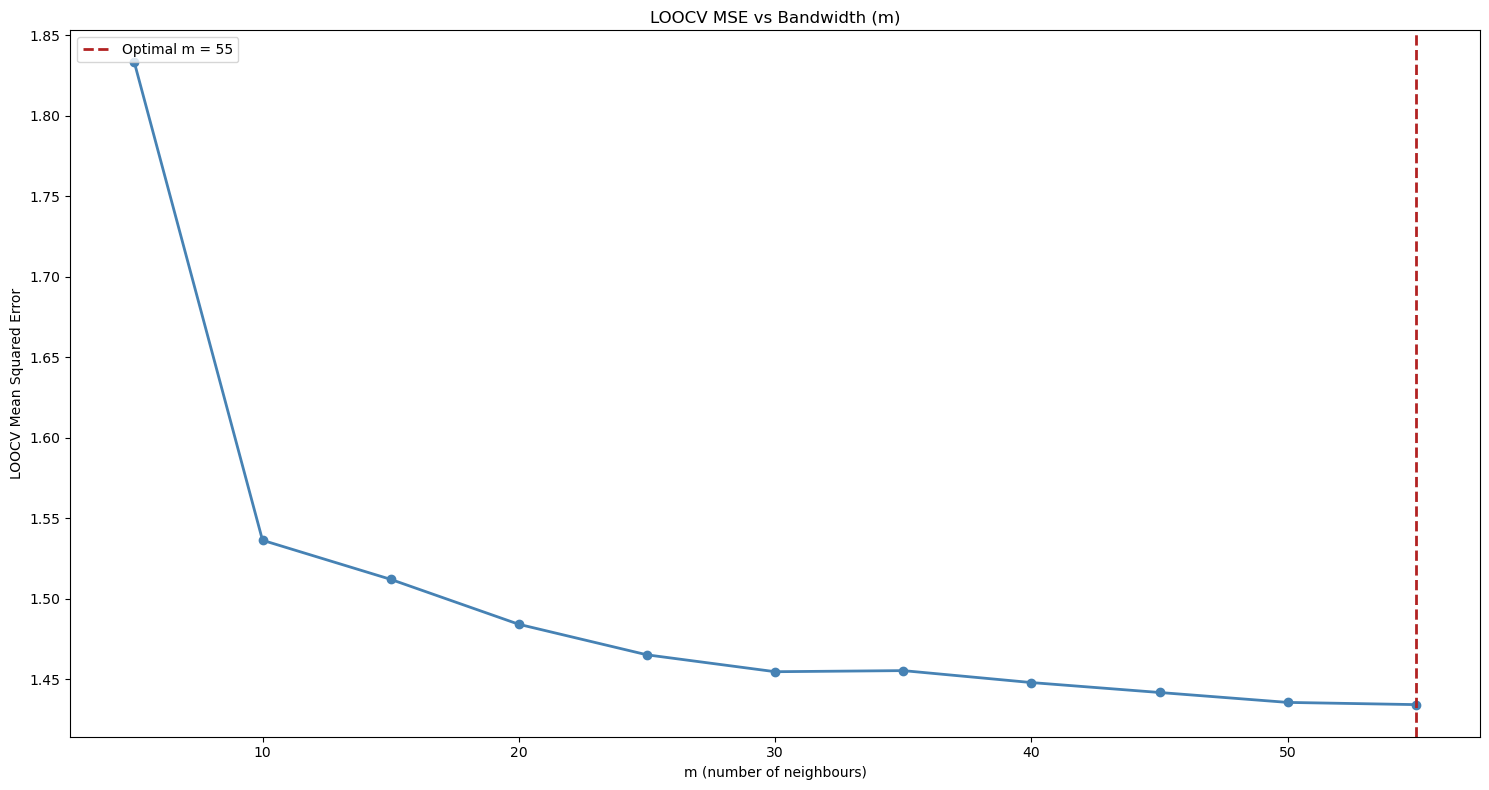

In [45]:
# ============================================================
# Plot LOOCV Error vs Bandwidth
# ============================================================
plt.figure(figsize=(15, 8))
plt.plot(list(m_candidates), cv_errors, 
         color='steelblue', linewidth=2, marker='o')
plt.axvline(x=optimal_m, color='firebrick', 
            linestyle='--', linewidth=2, 
            label=f'Optimal m = {optimal_m}')
plt.title('LOOCV MSE vs Bandwidth (m)')
plt.xlabel('m (number of neighbours)')
plt.ylabel('LOOCV Mean Squared Error')
plt.legend()
plt.tight_layout()
plt.show()

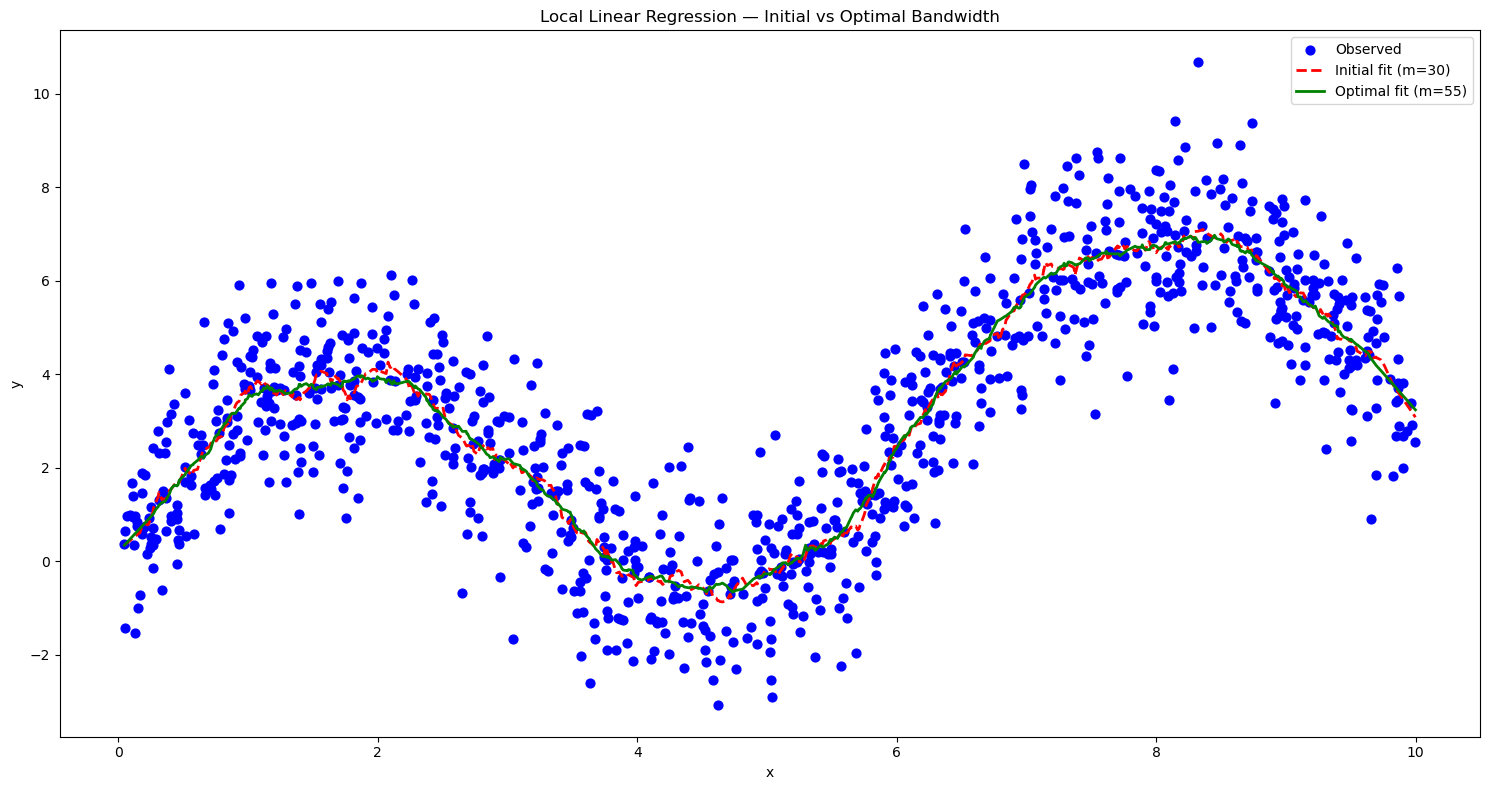

In [47]:
# ============================================================
# Refit with Optimal Bandwidth
# ============================================================
yh_optimal    = local_linear_fit(x, y, optimal_m)
df['yh_opt']  = yh_optimal

plt.figure(figsize=(15, 8))
plt.scatter(df['x'], df['y'],
            color='blue', s=40, label='Observed', zorder=2)
plt.plot(df['x'], df['yh'],
         color='red', linewidth=2, 
         linestyle='--', label=f'Initial fit (m=30)')
plt.plot(df['x'], df['yh_opt'],
         color='green', linewidth=2, 
         label=f'Optimal fit (m={optimal_m})')
plt.title('Local Linear Regression — Initial vs Optimal Bandwidth')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()